# MOP infrastructure & water finance — review notebook (v1)

Supply opportunities for **MOP** plus the program→action crosswalk. Loads the hand-curated supply table, validates it, renders the aggregates the review cites, then builds the mapping to the city action list (`actions_profiled.csv`).

Dataset README one level up; need `2026-06-cl-finance-opportunities`. Restart-and-run-all must pass. Charts render inline (never saved as files).

In [1]:
# Block 1 — parameters & imports (Mage-portable: paths are the only config)
%matplotlib inline
import csv, os, ast
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

SUPPLY_CSV = 'data/cl_mop_fondos_v1.csv'
MAP_CSV    = 'data/cl_mop_fondos_to_actions.csv'
ACTIONS    = '../../../../cl-ssg/cl-ssg-projects/releases/v1/data/derived/actions_profiled.csv'  # target taxonomy (102 city actions)
assert os.path.exists(SUPPLY_CSV), SUPPLY_CSV
assert os.path.exists(ACTIONS), ACTIONS
print('paths ok')

paths ok


In [2]:
# Block 2 — load the hand-curated supply table (no transformations; source has no PII)
supply = pd.read_csv(SUPPLY_CSV, dtype=str).fillna('')
print(f'{len(supply)} programs, {supply.shape[1]} cols')
supply[['program','instrument_type','recurrence','climate_relevance','gpc_sectors','status']].head(len(supply))

7 programs, 17 cols


,program,instrument_type,recurrence,climate_relevance,gpc_sectors,status
0,Agua Potable Rural / Servicios Sanitarios Rura...,grant (public investment),ongoing,explicit,"[""water"",""waste""]",ongoing
1,Conservación / mantención de sistemas APR,grant (public investment),ongoing,explicit,"[""water"",""waste""]",ongoing
2,Gestión de cuencas / aplicación Código de Agua...,technical_assistance + grant (research fund),ongoing,explicit,"[""water"",""afolu""]",ongoing
3,Programa Infraestructura para el Buen Vivir (P...,grant (budget transfer),time-boxed,climate-adjacent,"[""stationary_energy"",""transportation"",""waste"",...",ongoing
4,Fondo de Infraestructura para el Desarrollo,grant (budget transfer),time-boxed,climate-adjacent,"[""stationary_energy"",""transportation"",""waste"",...",ongoing
5,Plan de Infraestructura en Asociación Público-...,blended (PPP / concession),time-boxed,climate-adjacent,"[""stationary_energy"",""transportation""]",ongoing
6,Dirección de Arquitectura — Iniciativas de Inv...,grant (public investment),ongoing,indirect,"[""buildings"",""stationary_energy""]",ongoing


In [3]:
# Block 3 — validate: schema, controlled vocab, completeness (assertions, not eyeballing)
REQUIRED = ['program','funder_institution','instrument_type','recurrence','climate_relevance','gpc_sectors','source_url']
for c in REQUIRED: assert c in supply.columns, f'missing col {c}'
assert supply['program'].is_unique, 'duplicate program'
assert (supply['source_url'].str.startswith('http')).all(), 'every program needs a source_url'
VOCAB_REC = {'annual','ongoing','biennial-cycle','time-boxed'}
VOCAB_CR  = {'explicit','climate-adjacent','indirect'}
bad_rec = set(supply['recurrence']) - VOCAB_REC
bad_cr  = set(supply['climate_relevance']) - VOCAB_CR
assert not bad_rec, f'unexpected recurrence values: {bad_rec}'
assert not bad_cr,  f'unexpected climate_relevance values: {bad_cr}'
print('validation passed:', len(supply), 'programs, vocab clean, all source_urls present')

validation passed: 7 programs, vocab clean, all source_urls present


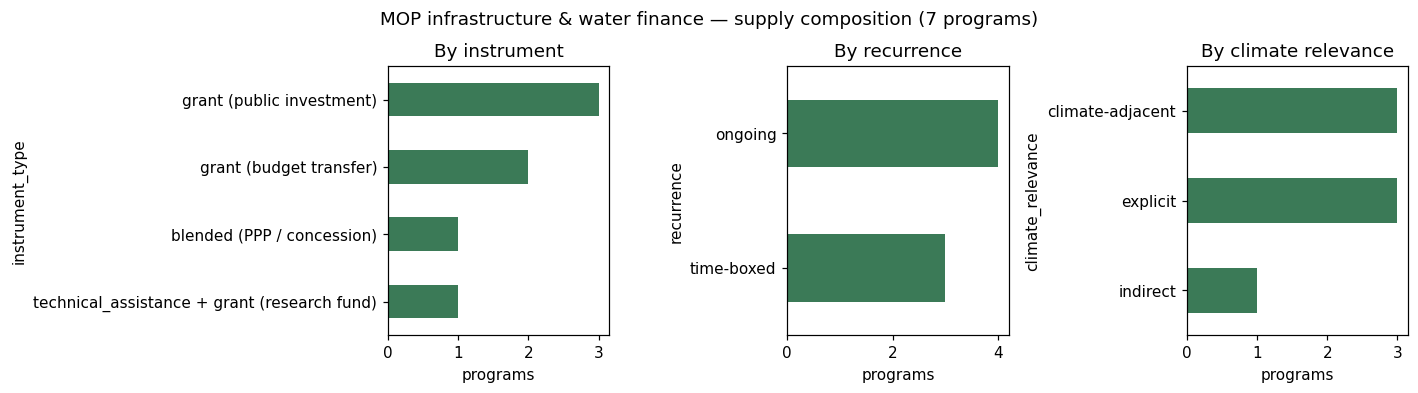

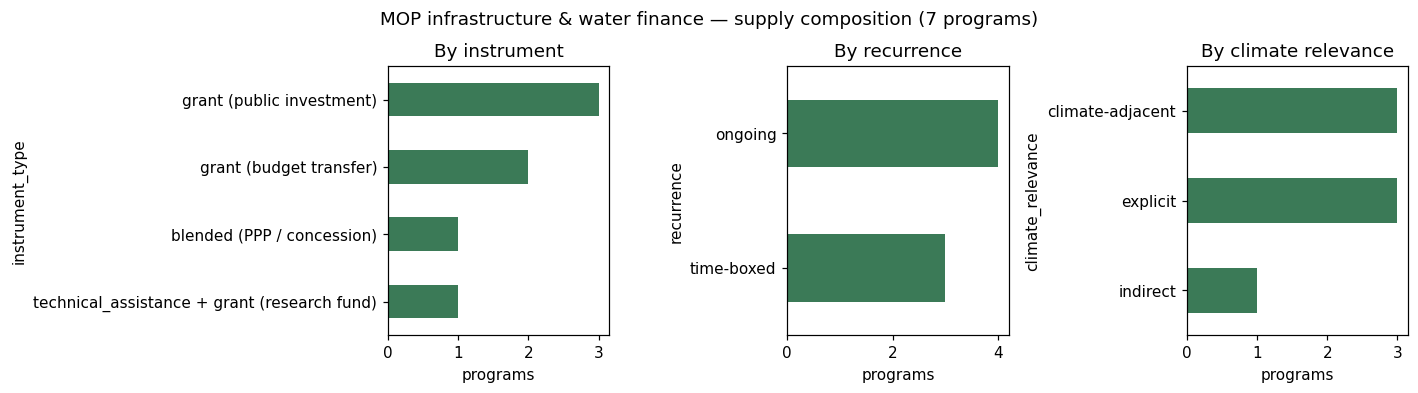

In [4]:
# Block 4 — aggregates the review cites (rendered inline; not saved as files)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, ttl in zip(axes,
        ['instrument_type','recurrence','climate_relevance'],
        ['By instrument','By recurrence','By climate relevance']):
    vc = supply[col].value_counts()
    vc.sort_values().plot.barh(ax=ax, color='#3b7a57')
    ax.set_title(ttl); ax.set_xlabel('programs')
fig.suptitle('MOP infrastructure & water finance — supply composition ({} programs)'.format(len(supply)))
fig.tight_layout(); fig.subplots_adjust(top=0.84)
fig

In [5]:
# Block 5 — program -> action mapping (curated; link-don't-attribute; one row per pair)
# mediums/lows/none are agent drafts AWAITING human adjudication.
actions = pd.read_csv(ACTIONS)
actions['id'] = actions[actions.columns[0]]
acat = {r['id']: (str(r['action_name']).strip(), r['gpc_reference_number']) for _, r in actions.iterrows()}

PROG_META = {
    'mop_apr_ssr': ('Agua Potable Rural / SSR — inversión', 'MOP/DOH', 'water', 'explicit'),
    'mop_apr_conservacion': ('Conservación de sistemas APR', 'MOP/DOH', 'water', 'explicit'),
    'mop_saneamiento_rural': ('Saneamiento rural', 'MOP/DOH', 'waste', 'explicit'),
    'mop_dga_cuencas': ('Gestión de cuencas (Leyes 20.998/21.435)', 'MOP/DGA', 'water', 'explicit'),
    'mop_pibv': ('Infraestructura para el Buen Vivir', 'MOP/DGOP', 'cross_sector', 'climate-adjacent'),
    'mop_fondo_infra': ('Fondo de Infraestructura para el Desarrollo', 'MOP/DGOP', 'cross_sector', 'climate-adjacent'),
    'mop_concesiones_app': ('Plan APP / Concesiones 2022-2026', 'MOP/DGC', 'cross_sector', 'climate-adjacent'),
    'mop_arquitectura': ('Dir. de Arquitectura — Iniciativas de Inversión', 'MOP/DA', 'buildings', 'indirect'),
}

MAPPING = [
    ('mop_apr_ssr', '', 'none', 'Rural drinking-water & sanitation is an adaptation/water-security program; the action list is mitigation-only and has no water-supply/security action.'),
    ('mop_apr_conservacion', '', 'none', 'Maintenance of rural water systems; same gap — no water-security action in a mitigation-only list.'),
    ('mop_saneamiento_rural', '', 'none', 'Rural sanitation; closest is wastewater biogas (icare_0031) but that is treatment-plant methane capture, not rural sanitation provision. No fit.'),
    ('mop_dga_cuencas', '', 'none', 'Water-rights/basin governance and water-research fund; statutory adaptation, no matching action.'),
    ('mop_pibv', '', 'none', 'Broad multi-sector rural infrastructure (roads, sanitation, rural buildings); maps only at project grain, not as a program.'),
    ('mop_fondo_infra', '', 'none', 'Cross-sector development-infrastructure transfer fund; too broad to map at program grain.'),
    ('mop_concesiones_app', '', 'none', 'Cross-sector PPP financing instrument (roads, hospitals, energy works); a finance vehicle, not an intervention.'),
    ('mop_arquitectura', 'c40_0017', 'medium', 'Public-building investment (Subt 31) can finance energy-efficient municipal buildings; medium for municipal-building retrofit.'),
    ('mop_arquitectura', 'c40_0012', 'low', 'Could fund energy-efficient new institutional buildings (schools/hospitals); low, conditional on scope.'),
]

rows = []
for pid, aid, conf, rat in MAPPING:
    pn, fund, sec, cr = PROG_META[pid]
    an, agpc = (acat[aid] if aid else ('', ''))
    if aid: assert aid in acat, f'unknown action {aid}'
    rows.append(dict(program_id=pid, program_name=pn, funder=fund, program_gpc_sector=sec,
                     program_climate_relevance=cr, action_id=aid, action_name=an,
                     action_gpc_ref=agpc, mapping_confidence=conf, rationale=rat))
xwalk = pd.DataFrame(rows)
xwalk[['program_id','action_id','mapping_confidence']].head(len(xwalk))

,program_id,action_id,mapping_confidence
0,mop_apr_ssr,,none
1,mop_apr_conservacion,,none
2,mop_saneamiento_rural,,none
3,mop_dga_cuencas,,none
4,mop_pibv,,none
5,mop_fondo_infra,,none
6,mop_concesiones_app,,none
7,mop_arquitectura,c40_0017,medium
8,mop_arquitectura,c40_0012,low


wrote data/cl_mop_fondos_to_actions.csv: 9 rows | 1 programs mapped, 7 none


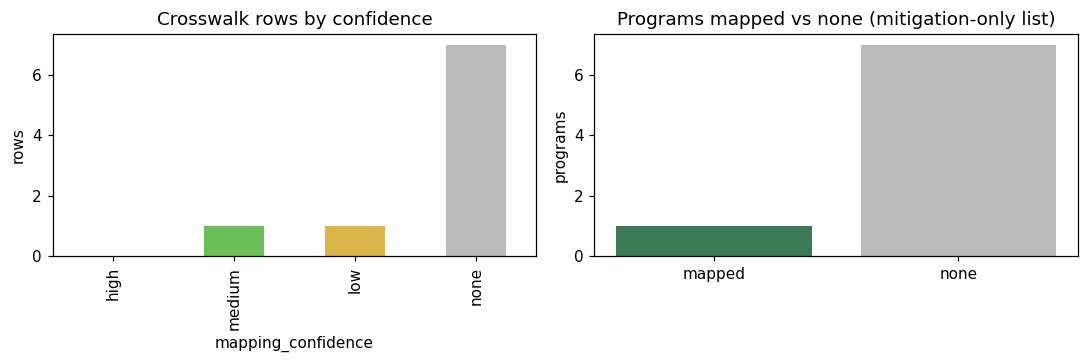

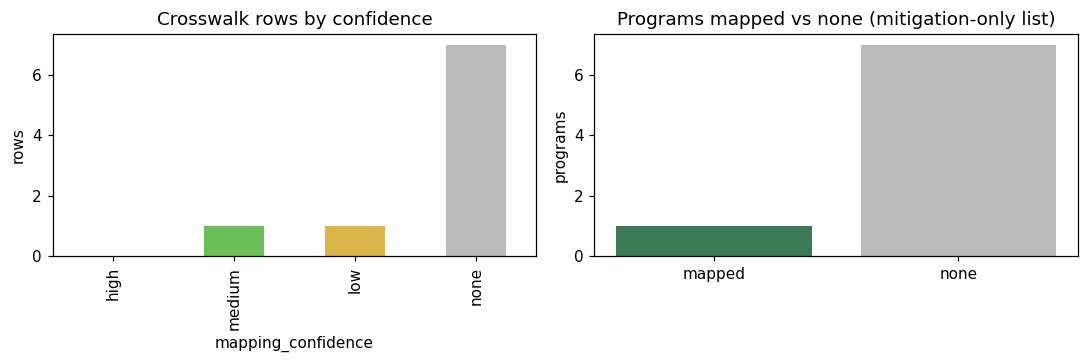

In [6]:
# Block 6 — validate mapping, export crosswalk, render coverage (both directions)
progs = set(PROG_META)
assert progs == set(xwalk['program_id']), 'every program must appear (mapped or none)'
pairs = xwalk.loc[xwalk['action_id'] != '', ['program_id','action_id']]
assert not pairs.duplicated().any(), 'duplicate (program, action) pair'
for aid in xwalk.loc[xwalk['action_id'] != '', 'action_id']:
    assert aid in acat, f'unresolved target {aid}'
xwalk.to_csv(MAP_CSV, index=False)

mapped = xwalk.loc[xwalk['mapping_confidence'] != 'none', 'program_id'].nunique()
none_n = len(progs) - mapped
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
xwalk['mapping_confidence'].value_counts().reindex(['high','medium','low','none']).fillna(0).plot.bar(
    ax=ax[0], color=['#1a7a3a','#6bbf59','#d9b54a','#bbbbbb'])
ax[0].set_title('Crosswalk rows by confidence'); ax[0].set_ylabel('rows')
ax[1].bar(['mapped','none'], [mapped, none_n], color=['#3b7a57','#bbbbbb'])
ax[1].set_title('Programs mapped vs none (mitigation-only list)'); ax[1].set_ylabel('programs')
fig.tight_layout()
print(f'wrote {MAP_CSV}: {len(xwalk)} rows | {mapped} programs mapped, {none_n} none')
fig

## Findings

- Supply table validates (unique programs, clean controlled vocab, every program has a `source_url`).
- The program→action crosswalk is the second committed `data/` output; quantities stay at program grain (link, don't attribute) so an award/amount on a program weights its mapped actions, never split across them.
- Coverage is reported both directions in the charts above; unreached-target and `none` reasons live in the rationale column and flow into `review.md`.
- All medium/low/none rows are agent drafts and **await human adjudication**.